# IT Support Dashboard - Supporting Notebook 2

This notebook evaluates whether the English-language subset remains representative of the cleaned ticket population. The result determines whether downstream English-only text modelling can proceed with controlled distributional risk.

## Representativeness Check

This notebook quantifies how much composition changes when the dataset is restricted to `Language == "EN"`.

Included checks:
- category-level shifts via `Signed Pct Diff`
- dimension-level drift via `L1 Total Abs Pct Diff`
- inferential difference tests using `chi-square`
- practical effect size assessment with `Cramer's V`

The output is a transparent decision gate (`PASS`, `PASS with caution`, or `FAIL`) used to approve or block downstream English-only analysis.

### Importing

Packages are imported, project directories are validated with `Config.ensure_directories()`, and the cleaned source dataset from Notebook 1 is loaded.

Value: this establishes a reproducible baseline before any language filtering or distribution testing.

In [1]:
# Importing essential packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Add project root to sys.path by searching upward for config.py
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists()), None
)
if project_root is None:
    raise FileNotFoundError("Could not locate project root containing config.py")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config import Config  # noqa: E402

Config.ensure_directories()

# Reading the initial dataset as a DataFrame: df
df = pd.read_parquet(Config.CLEAN_PARQUET_PATH, engine="pyarrow")

display(df)

[Config] Verified project directory structure under C:\Users\David\Desktop\Python_Files\IT-Support-Ticket-Analysis


,Index,Subject,Body,Answer,Type,Queue,Priority,Language,Version,Tag_1,Tag_2,Tag_3,Tag_4,Tag_5,Tag_6,Tag_7,Tag_8
0,0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team, ich möchte einen g...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,High,DE,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,1,Account Disruption,"Dear Customer Support Team, I am writing to re...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,High,EN,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team, I hope this messag...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,Medium,EN,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,3,Inquiry Regarding Invoice Details,"Dear Customer Support Team, I hope this messag...",We appreciate you reaching out with your billi...,Request,Billing and Payments,Low,EN,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,4,Question About Marketing Agency Software Compa...,"Dear Support Team, I hope this message reaches...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,Medium,EN,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24738,28582,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,High,EN,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
24739,28583,Datensperrung in der Kundschaftsbetreuung,"Es gab einen Datensperrungsunfall, bei dem ung...",Ich kann Ihnen bei dem Datensperrungsunfall he...,Incident,Product Support,High,DE,400,Security,IT,Tech Support,Bug,NaN,NaN,NaN,NaN
24740,28584,Problem mit der Videokonferenz-Software heute,Wichtigere Sitzungen wurden unterbrochen durch...,"Sehr geehrte/r [Name], leider wurde das Proble...",Incident,Human Resources,Low,DE,400,Bug,Performance,Network,IT,Tech Support,NaN,NaN,NaN
24741,28585,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,High,EN,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN


### Subsetting English Data

English records account for `55.49%` (`13,729`) of all tickets.

Value: this confirms the scale reduction introduced by language filtering and justifies formal representativeness checks before modelling.

In [2]:
# Create language-specific subsets
df_en = df[df["Language"] == "EN"].copy()
df_de = df[df["Language"] == "DE"].copy()

# Saving the English-only subset to CSV and Parquet
df_en.to_csv(Config.ENGLISH_CSV_PATH, index=False, encoding="latin-1")
df_en.to_parquet(
    Config.ENGLISH_PARQUET_PATH,
    index=False,
    engine="pyarrow",
    compression="snappy",
)

# Calculate language composition
english_percentage = len(df_en) / len(df)
german_percentage = len(df_de) / len(df)

print(f"\nEnglish-only rows: {len(df_en):,}, accounting for {english_percentage:.2%}")
print(f"\nGerman-only rows: {len(df_de):,}, accounting for {german_percentage:.2%}")


English-only rows: 13,729, accounting for 55.49%

German-only rows: 11,014, accounting for 44.51%


### Proportion Shift Diagnostics

This step measures distribution shifts between the full dataset and the English subset.

Value obtained:
- identifies where English filtering over- or under-represents categories
- quantifies practical drift by dimension
- provides evidence for whether downstream findings can be generalised to the full service population

In [3]:
# Define a function to compare distributions of a categorical column between the English-only subset and the full dataset
def compare_distribution(col, top_n=None):
    """Produce comparison table for a categorical column."""
    full_counts = df[col].value_counts(dropna=False)
    en_counts = df_en[col].value_counts(dropna=False)

    full_total = full_counts.sum()
    en_total = en_counts.sum()

    # Align both count Series by their shared index (all categories in either dataset)
    result = (
        pd.DataFrame({"English Count": en_counts, "Full Count": full_counts})
        .fillna(0)
        .astype({"English Count": int, "Full Count": int})
        .sort_values("Full Count", ascending=False)
    )

    if top_n is not None:
        result = result.head(top_n)

    result["English Pct"] = result["English Count"] / en_total
    result["Full Pct"] = result["Full Count"] / full_total
    result["Signed Pct Diff"] = result["English Pct"] - result["Full Pct"]
    result["Absolute Pct Diff"] = result["Signed Pct Diff"].abs()
    result["Rel Signed Pct Diff"] = result["Signed Pct Diff"] / result[
        "Full Pct"
    ].replace(0, np.nan)

    return result.reset_index(names=col)


# Compute distributions and summary metrics
distributions = {}
summary = []
comparison_cols = {"02": "Priority", "03": "Type", "04": "Queue", "05": "Version"}

# Loop through dimensions to produce summary tables for shift diagnostics
for position, col in comparison_cols.items():
    # Error message for missed dimensions
    if col not in df.columns:
        print(f"WARNING: column '{col}' not in dataset - skipping.")
        continue

    print(f"\nDistributions table for {col} column:")

    dist = compare_distribution(col)
    distributions[col] = dist

    # L1 metric (sum absolute proportion diffs)
    l1_total = dist["Absolute Pct Diff"].sum()
    idx_max = dist["Absolute Pct Diff"].idxmax()
    max_cat = dist.loc[idx_max, col]
    max_signed = dist.loc[idx_max, "Signed Pct Diff"]
    max_abs = dist.loc[idx_max, "Absolute Pct Diff"]

    summary.append(
        {
            "Dimension": col,
            "Max Diff Category": max_cat,
            "Signed Pct Diff at Max": max_signed,
            "L1 Total Abs Pct Diff": l1_total,
            "Max Abs Pct Diff": max_abs,
        }
    )

    dist.sort_values("Absolute Pct Diff", ascending=False, inplace=True)

    display(
        dist.style.format(
            {
                "English Count": "{:,}",
                "Full Count": "{:,}",
                "English Pct": "{:.2%}",
                "Full Pct": "{:.2%}",
                "Signed Pct Diff": "{:+.3%}",
                "Absolute Pct Diff": "{:.3%}",
                "Rel Signed Pct Diff": "{:+.3%}",
            }
        )
    )

    dist.to_csv(
        Config.REP_SHEETS_DIR / f"{position}_Distribution_Comparison_{col}.csv",
        index=False,
        encoding="latin-1",
    )

# Create the summary of distributions dataframe
absolute_shifts_df = pd.DataFrame(summary)
absolute_shifts_df.sort_values("L1 Total Abs Pct Diff", ascending=False, inplace=True)

print("\nSummary of distribution shifts:")

display(
    absolute_shifts_df.style.format(
        {
            "Signed Pct Diff at Max": "{:+.2%}",
            "L1 Total Abs Pct Diff": "{:.2%}",
            "Max Abs Pct Diff": "{:.2%}",
        }
    )
)

absolute_shifts_df.to_csv(Config.ABSOLUTE_SHIFT_PATH, index=False, encoding="latin-1")


Distributions table for Priority column:


,Priority,English Count,Full Count,English Pct,Full Pct,Signed Pct Diff,Absolute Pct Diff,Rel Signed Pct Diff
0,Medium,"5,593","9,975",40.74%,40.31%,+0.424%,0.424%,+1.052%
1,High,"5,304","9,653",38.63%,39.01%,-0.380%,0.380%,-0.973%
2,Low,"2,832","5,115",20.63%,20.67%,-0.045%,0.045%,-0.216%



Distributions table for Type column:


,Type,English Count,Full Count,English Pct,Full Pct,Signed Pct Diff,Absolute Pct Diff,Rel Signed Pct Diff
2,Problem,"2,872","5,230",20.92%,21.14%,-0.218%,0.218%,-1.032%
3,Change,"1,397","2,484",10.18%,10.04%,+0.136%,0.136%,+1.358%
0,Incident,"5,531","9,950",40.29%,40.21%,+0.074%,0.074%,+0.183%
1,Request,"3,929","7,079",28.62%,28.61%,+0.008%,0.008%,+0.028%



Distributions table for Queue column:


,Queue,English Count,Full Count,English Pct,Full Pct,Signed Pct Diff,Absolute Pct Diff,Rel Signed Pct Diff
1,Product Support,"2,606","4,560",18.98%,18.43%,+0.552%,0.552%,+2.997%
0,Technical Support,"3,971","7,260",28.92%,29.34%,-0.417%,0.417%,-1.423%
2,Customer Service,"2,045","3,732",14.90%,15.08%,-0.188%,0.188%,-1.244%
3,IT Support,"1,609","2,943",11.72%,11.89%,-0.175%,0.175%,-1.468%
8,Human Resources,285,473,2.08%,1.91%,+0.164%,0.164%,+8.592%
7,Sales and Pre-Sales,410,763,2.99%,3.08%,-0.097%,0.097%,-3.156%
6,Service Outages and Maintenance,581,"1,024",4.23%,4.14%,+0.093%,0.093%,+2.256%
5,Returns and Exchanges,686,"1,226",5.00%,4.95%,+0.042%,0.042%,+0.843%
4,Billing and Payments,"1,349","2,425",9.83%,9.80%,+0.025%,0.025%,+0.257%
9,General Inquiry,187,337,1.36%,1.36%,+0.000%,0.000%,+0.006%



Distributions table for Version column:


,Version,English Count,Full Count,English Pct,Full Pct,Signed Pct Diff,Absolute Pct Diff,Rel Signed Pct Diff
0,400,"8,861","16,263",64.54%,65.73%,-1.185%,1.185%,-1.804%
1,52,"4,317","7,611",31.44%,30.76%,+0.684%,0.684%,+2.224%
2,51,551,869,4.01%,3.51%,+0.501%,0.501%,+14.273%



Summary of distribution shifts:


,Dimension,Max Diff Category,Signed Pct Diff at Max,L1 Total Abs Pct Diff,Max Abs Pct Diff
3,Version,400,-1.19%,2.37%,1.19%
2,Queue,Product Support,+0.55%,1.75%,0.55%
0,Priority,Medium,+0.42%,0.85%,0.42%
1,Type,Problem,-0.22%,0.44%,0.22%


### Visualising Distribution Comparisons

This section visualises `English` versus `Full` distributions for each monitored dimension.

Value: charts make the direction and practical size of shifts easier to inspect before interpreting statistical gate outcomes.


Proportions table for Priority:


,Priority,Dataset,Proportion
0,Medium,Full (English + German),0.403144
1,High,Full (English + German),0.390131
2,Low,Full (English + German),0.206725
3,Medium,English-Only,0.407386
4,High,English-Only,0.386335
5,Low,English-Only,0.206279


Visual for Priority:


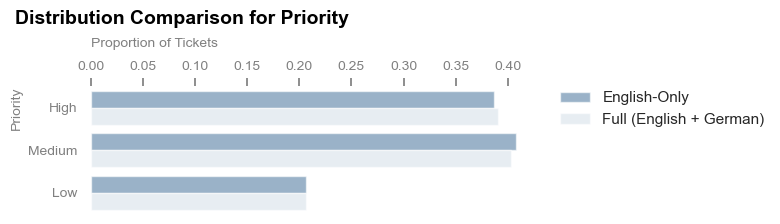


Proportions table for Type:


,Type,Dataset,Proportion
0,Problem,Full (English + German),0.211373
1,Change,Full (English + German),0.100392
2,Incident,Full (English + German),0.402134
3,Request,Full (English + German),0.286101
4,Problem,English-Only,0.209192
5,Change,English-Only,0.101755
6,Incident,English-Only,0.402870
7,Request,English-Only,0.286183


Visual for Type:


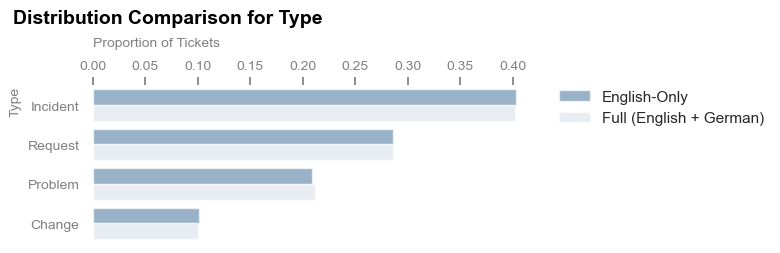


Proportions table for Queue:


,Queue,Dataset,Proportion
0,Product Support,Full (English + German),0.184295
1,Technical Support,Full (English + German),0.293416
2,Customer Service,Full (English + German),0.150831
3,IT Support,Full (English + German),0.118943
4,Human Resources,Full (English + German),0.019117
5,Sales and Pre-Sales,Full (English + German),0.030837
6,Service Outages and Maintenance,Full (English + German),0.041385
7,Returns and Exchanges,Full (English + German),0.049549
8,Billing and Payments,Full (English + German),0.098008
9,General Inquiry,Full (English + German),0.013620


Visual for Queue:


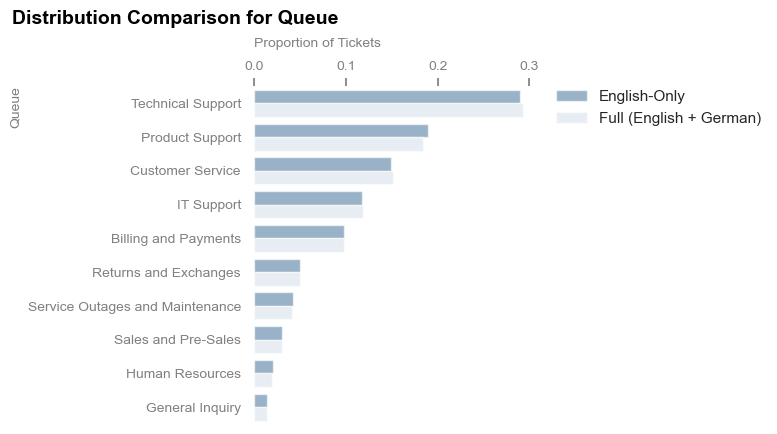


Proportions table for Version:


,Version,Dataset,Proportion
0,400,Full (English + German),0.657277
1,52,Full (English + German),0.307602
2,51,Full (English + German),0.035121
3,400,English-Only,0.645422
4,52,English-Only,0.314444
5,51,English-Only,0.040134


Visual for Version:


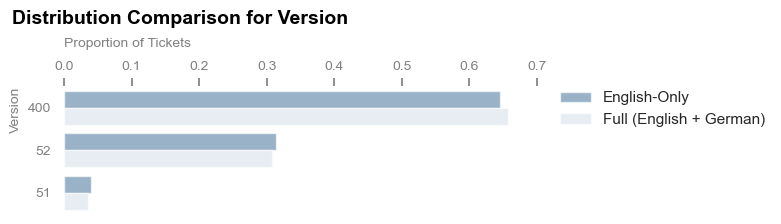

In [4]:
# Apply Seaborn theme globally
sns.set_theme(style="white")

# Collect visual parameters across all dimensions
visual_params_records = []

# Loop through columns to plot each distribution comparison
for position, col in comparison_cols.items():
    if col not in distributions:
        continue

    tbl = distributions[col]

    # Prepare tidy data for Seaborn (long-form melt)
    df_plot = tbl.melt(
        id_vars=[col],
        value_vars=["Full Pct", "English Pct"],
        var_name="Dataset",
        value_name="Proportion",
    )

    # Replace dataset labels for better readability of the legend
    df_plot["Dataset"] = df_plot["Dataset"].replace(
        {"Full Pct": "Full (English + German)", "English Pct": "English-Only"}
    )
    df_plot["Dataset"] = pd.Categorical(
        df_plot["Dataset"],
        categories=["English-Only", "Full (English + German)"],
        ordered=True,
    )

    # Export table used for visuals
    df_plot_temp = df_plot.copy()
    df_plot_temp["Dimension"] = col
    df_plot_temp = df_plot_temp.rename(columns={col: "Category"})
    visual_params_records.append(df_plot_temp)

    # Ensure Version is treated as categorical string for proper plotting
    if col == "Version":
        df_plot[col] = df_plot[col].astype(str)

    print(f"\nProportions table for {col}:")
    display(df_plot)

    # Order categories for plotting
    if col == "Priority":
        order = ["High", "Medium", "Low"]
    elif col == "Version":
        order = ["400", "52", "51"]
    else:
        # Default sort is with largest proportions at the top for better readability
        order = (
            df_plot.groupby(col, observed=True)["Proportion"]
            .mean()
            .sort_values(ascending=False)
            .index.tolist()
        )

    # Setting the size of the plot based on the number of categories
    num_cats = df_plot[col].nunique()
    fig_height = 1.5 + num_cats * 0.3
    fig_width = max(8, 1.5 + num_cats * 0.6)

    # Initialize the matplotlib figure
    f, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Create horizontal bar plot
    sns.barplot(
        data=df_plot,
        x="Proportion",
        y=col,
        hue="Dataset",
        saturation=0.7,
        palette=["steelblue", "#D3E1EE"],
        order=order,
        alpha=0.6,
    )

    # Set x-axis ticks based on maximum proportion for better readability
    if df_plot["Proportion"].max() > 0.6:
        ax.xaxis.set_ticks(np.arange(0, 0.71, 0.1))

    # Clean borders by removing bottom/right spines
    sns.despine(left=True, top=True, bottom=True, right=True)

    # Set labels and markers to grey for subtlety
    ax.set_xlabel("Proportion of Tickets", color="grey")
    ax.set_ylabel(col, color="grey")
    ax.tick_params(colors="grey")

    # Default x position for title
    if col == "Priority":
        x = -0.17
        loc = "left"
        leg_y = 1.07
    elif col == "Type":
        x = -0.18
        loc = "left"
        leg_y = 1.06
    elif col == "Queue":
        x = 0.3
        loc = "right"
        leg_y = 1.03
    else:
        x = -0.11
        loc = "left"
        leg_y = 1.07

    # Set font size to 10 for better readability and align labels to the left
    ax.yaxis.label.set_size(10)
    ax.xaxis.label.set_size(10)
    ax.tick_params(labelsize=10)

    # X-axis on top for better readability
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.xaxis.label.set_horizontalalignment("left")
    ax.xaxis.label.set_position((0, leg_y))
    ax.xaxis.labelpad = 10  # Add padding to the x-axis label for better spacing

    # Y-axis label alignment and position for better aesthetics
    ax.yaxis.label.set_horizontalalignment("right")
    ax.yaxis.label.set_position((0, 1))

    # Set title with font size 14 and grey color for subtlety
    ax.set_title(
        f"Distribution Comparison for {col}",
        fontsize=14,
        fontweight="bold",
        color="black",
        pad=10,
        loc=loc,
        x=x,
    )

    # Move legend to the right side of the plot
    ax.legend(bbox_to_anchor=(1.02, leg_y), loc="upper left", edgecolor="white")

    # Adjust layout and save figure
    plt.tight_layout()
    image_path = Config.REP_IMG_DIR / f"{position}_Distribution_Comparison_{col}.png"
    plt.savefig(image_path, dpi=300, bbox_inches="tight")

    print(f"Visual for {col}:")
    plt.show()

# Re-order columns and save visual parameters once
if visual_params_records:
    visual_params_df = pd.concat(visual_params_records, ignore_index=True)
    visual_params_df = visual_params_df[
        ["Dimension", "Dataset", "Category", "Proportion"]
    ]
    visual_params_df.to_csv(Config.VISUAL_PARAMS_PATH, index=False, encoding="utf-8")

### Chi-Square And Cramer's V Tests

This stage combines inferential and practical checks:
- `chi-square` and Benjamini-Hochberg-adjusted `p-values` identify detectable distribution differences
- `Cramer's V` evaluates practical effect size
- `L1 Total Abs Pct Diff` flags dimensions with meaningful aggregate drift

Decision framework:
- primary gate: `Cramer's V < 0.10` across all dimensions
- caution flags: `L1 > 2%` and/or adjusted `p-value < 0.05`

Value: the gate provides a consistent, auditable rule for approving downstream English-only modelling.

In [5]:
# Define parameters for Cramer's V test: chi2: chi-square result, n: sample size, r: number of rows, k: number of columns
def cramers_v(chi2, n, r, k):
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))


def benjamini_hochberg(pvals):
    """Return Benjamini-Hochberg adjusted p-values (FDR control)."""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = np.empty(m, dtype=float)

    # Work backwards to enforce monotonicity
    prev = 1.0
    for i in range(m - 1, -1, -1):
        rank = i + 1
        val = (ranked[i] * m) / rank
        prev = min(prev, val)
        adj[i] = prev

    p_adj = np.empty(m, dtype=float)
    p_adj[order] = np.clip(adj, 0, 1)
    return p_adj


# Initialise outputs array for stats results
tests = []

for col in distributions.keys():
    # Contingency table: rows=categories, cols=counts [English, German]
    en_counts = df_en[col].value_counts(dropna=False)
    de_counts = df_de[col].value_counts(dropna=False)

    ct = (
        pd.DataFrame({"EN Count": en_counts, "DE Count": de_counts})
        .fillna(0)
        .astype(int)
        .values
    )

    chi2, p, dof, expected = stats.chi2_contingency(ct, correction=False)
    n = ct.sum()
    r, k = ct.shape
    v = cramers_v(chi2, n, r, k)

    tests.append(
        {
            "Dimension": col,
            "Chi2": chi2,
            "P Value": p,
            "DoF": dof,
            "n": n,
            "Cramers V": v,
        }
    )

# Produce a dataframe using the stats result array
stats_df = pd.DataFrame(tests)
stats_df["P Value Adj Bh"] = benjamini_hochberg(stats_df["P Value"].values)

# Merge practical and inferential metrics for decision gate
decision_df = stats_df.merge(
    absolute_shifts_df[["Dimension", "L1 Total Abs Pct Diff"]],
    on="Dimension",
    how="left",
)

# Gate thresholds from shared config
MAX_CRAMERS_V = Config.REPRESENTATIVENESS_MAX_CRAMERS_V
MAX_L1 = Config.REPRESENTATIVENESS_MAX_L1
ALPHA_FDR = Config.REPRESENTATIVENESS_ALPHA_FDR

decision_df["Pass Cramers V"] = decision_df["Cramers V"] < MAX_CRAMERS_V
decision_df["L1 Exceeds Threshold"] = decision_df["L1 Total Abs Pct Diff"] > MAX_L1
decision_df["Caution Inferential"] = decision_df["P Value Adj Bh"] < ALPHA_FDR
decision_df["Any Caution"] = (
    decision_df["L1 Exceeds Threshold"] | decision_df["Caution Inferential"]
)

primary_gate_pass = bool(decision_df["Pass Cramers V"].all())
any_l1_caution = bool(decision_df["L1 Exceeds Threshold"].any())
any_inferential_caution = bool(decision_df["Caution Inferential"].any())
any_caution = bool(decision_df["Any Caution"].any())

l1_exceeded_dims = decision_df.loc[
    decision_df["L1 Exceeds Threshold"], "Dimension"
].tolist()
inferential_caution_dims = decision_df.loc[
    decision_df["Caution Inferential"], "Dimension"
].tolist()
cramers_fail_dims = decision_df.loc[
    ~decision_df["Pass Cramers V"], "Dimension"
].tolist()

stats_df.to_csv(
    Config.STATISTICAL_SUMMARY_PATH,
    index=False,
    encoding="utf-8",
    float_format="%.3e",
)

print(
    "\nChi-square and Cramer's V test results for English vs German distribution differences:"
)
display(
    stats_df.style.format(
        {
            "Chi2": "{:.3f}",
            "P Value": "{:.2e}",
            "P Value Adj Bh": "{:.2e}",
            "n": "{:,}",
            "Cramers V": "{:.3f}",
        }
    )
)

print("\nRepresentativeness decision gate by dimension:")
display(
    decision_df.style.format(
        {
            "Cramers V": "{:.3f}",
            "L1 Total Abs Pct Diff": "{:.2%}",
            "P Value": "{:.2e}",
            "P Value Adj Bh": "{:.2e}",
        }
    )
)

print("\nFinal gate result:")
if primary_gate_pass and not any_caution:
    print(
        "PASS: English subset is representative under the primary effect-size gate, with no caution flags."
    )
elif primary_gate_pass and any_caution:
    reasons = []
    if any_l1_caution:
        reasons.append(
            f"total absolute shift exceeded {MAX_L1:.0%} in the following dimensions ("
            + ", ".join(l1_exceeded_dims)
            + ")"
        )
    if any_inferential_caution:
        reasons.append(
            "adjusted p-values indicate detectable differences in ("
            + ", ".join(inferential_caution_dims)
            + ")"
        )

    print("PASS with caution: " + "; ".join(reasons) + ".")
else:
    fail_dims_text = ", ".join(cramers_fail_dims) if cramers_fail_dims else "None"
    print(
        "FAIL: English subset does not satisfy the primary representativeness gate "
        "(Cramer's V threshold exceeded) in the following dimensions ("
        + fail_dims_text
        + ")."
    )


Chi-square and Cramer's V test results for English vs German distribution differences:


,Dimension,Chi2,P Value,DoF,n,Cramers V,P Value Adj Bh
0,Priority,2.545,2.80e-01,2,"24,743",0.010,3.74e-01
1,Type,1.307,7.27e-01,3,"24,743",0.007,7.27e-01
2,Queue,14.524,1.05e-01,9,"24,743",0.024,2.10e-01
3,Version,33.356,5.71e-08,2,"24,743",0.037,2.28e-07



Representativeness decision gate by dimension:


,Dimension,Chi2,P Value,DoF,n,Cramers V,P Value Adj Bh,L1 Total Abs Pct Diff,Pass Cramers V,L1 Exceeds Threshold,Caution Inferential,Any Caution
0,Priority,2.544674,2.80e-01,2,24743,0.010,3.74e-01,0.85%,True,False,False,False
1,Type,1.307189,7.27e-01,3,24743,0.007,7.27e-01,0.44%,True,False,False,False
2,Queue,14.523612,1.05e-01,9,24743,0.024,2.10e-01,1.75%,True,False,False,False
3,Version,33.356253,5.71e-08,2,24743,0.037,2.28e-07,2.37%,True,True,True,True



Final gate result:
PASS with caution: total absolute shift exceeded 2% in the following dimensions (Version); adjusted p-values indicate detectable differences in (Version).


Representativeness is concluded from a primary practical gate (`Cramer's V`) plus caution diagnostics (`L1` drift and adjusted `p-values`).

Category tables retain signed shifts for interpretability, while the decision gate aggregates absolute shift magnitude for practical risk assessment.

Value: this notebook produces a clear go/no-go decision for downstream text work.

Handoff to Notebook 3: when the gate is acceptable, the approved English subset is used for text normalisation, similarity profiling, and recurrence measurement.